In [2]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from typing import List, Tuple

# --- Loading (no trimming) ---
def load_brainflow_raw(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, comment='%', header=0)
    df.columns = df.columns.str.strip()
    if "Timestamp" not in df.columns:
        raise KeyError(f"No 'Timestamp' column in {filepath}. Columns: {df.columns.tolist()}")
    return df

# --- Utility: list EEG cols ---
def list_eeg_cols(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if "EXG Channel" in c]

# --- Parse manual selection like '0,2,5-7' or 'all' ---
def parse_selection(txt: str, max_idx: int) -> List[int]:
    txt = txt.strip().lower()
    if txt in ("", "none", "skip"):
        return []
    if txt in ("all", "a"):
        return list(range(max_idx))
    picked = set()
    for part in txt.split(","):
        part = part.strip()
        if "-" in part:
            a, b = part.split("-")
            a, b = int(a), int(b)
            for i in range(min(a,b), max(a,b)+1):
                if 0 <= i < max_idx:
                    picked.add(i)
        else:
            i = int(part)
            if 0 <= i < max_idx:
                picked.add(i)
    return sorted(picked)


In [4]:
from scipy.signal import butter, filtfilt

def bandpass_filter(data, low=1.0, high=40.0, fs=250, order=4):
    """Standard EEG bandpass filter."""
    nyq = 0.5 * fs
    low /= nyq
    high /= nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data)

def attenuate_channel(data, factor=0.5):
    """Attenuate dead/noisy channel."""
    return data * factor


In [5]:
def manual_select_channels_with_mapping(filepaths: List[str], target_channels: int):
    """
    Ask user to select channels, map them to output EXG indices,
    and decide if filtering is applied.
    
    Returns:
      dfs: list of raw DataFrames
      mapping: list of dicts {file_idx, orig_col, output_idx, filter_type}
    """
    dfs = [load_brainflow_raw(fp) for fp in filepaths]
    mapping = []
    
    for file_idx, (fp, df) in enumerate(zip(filepaths, dfs)):
        eeg_cols = list_eeg_cols(df)
        if not eeg_cols:
            print(f"\n{fp}\n  No EEG columns found.")
            continue
        
        print(f"\nFile {file_idx}: {fp}")
        print("Available channels (index: name):")
        for i, c in enumerate(eeg_cols):
            s = df[c]
            print(f"  {i:2d}: {c:>14s}  mean={s.mean():8.2f}  std={s.std():8.2f}")
        
        inp = input("Pick channels (e.g., '0,2,5', or 'skip' to skip this file): ").strip().lower()
        if inp in ("skip", ""):
            continue
        
        idxs = parse_selection(inp, max_idx=len(eeg_cols))
        for i in idxs:
            col = eeg_cols[i]
            # Ask which EXG channel to map to
            out_idx = int(input(f"Map {col} (File {file_idx}) → EXG output index (1–{target_channels}, 0=skip): "))
            if out_idx == 0:
                print(f"  Skipping {col}")
                continue
            if not (1 <= out_idx <= target_channels):
                print(f"  Invalid index {out_idx}, skipping channel.")
                continue
            
            # Ask filter type
            filt_inp = input(f"Apply filter to {col}? (b = bandpass, a = attenuate, n = none): ").strip().lower()
            if filt_inp == "b":
                ftype = "bandpass"
            elif filt_inp == "a":
                ftype = "attenuate"
            else:
                ftype = "none"
            
            mapping.append({
                "file_idx": file_idx,
                "orig_col": col,
                "output_idx": out_idx - 1,  # store as 0-based
                "filter_type": ftype
            })
    
    return dfs, mapping


In [8]:
def merge_with_mapping(dfs: List[pd.DataFrame],
                       mapping: List[dict],
                       max_channels: int,
                       fs: int = 250) -> Tuple[pd.DataFrame, List[str]]:
    """
    Merge multiple DataFrames using user-provided mapping with optional filters.
    Aligns by sample index (assumes same sample rate), not absolute timestamps.
    """
    # Collect per-file selections
    per_file = []
    for file_idx, df in enumerate(dfs):
        chosen_here = [m["orig_col"] for m in mapping if m["file_idx"] == file_idx]
        if not chosen_here:
            continue
        sub = df[["Timestamp"] + chosen_here].copy()
        sub = sub.rename(columns={c: f"File{file_idx}_{c}" for c in chosen_here})
        per_file.append(sub.reset_index(drop=True))  # align by index, not timestamp

    if not per_file:
        raise ValueError("❌ No dataframes to merge. Check selections.")

    # --- Truncate to shortest file length ---
    min_len = min(len(df) for df in per_file)
    aligned = [df.iloc[:min_len] for df in per_file]
    merged = pd.concat(aligned, axis=1)

    # --- Build synthetic timestamp axis ---
    common_time = np.arange(min_len) / fs

    # --- Prepare output DataFrame ---
    final_df = pd.DataFrame(index=range(min_len))
    exg_cols = [f"EXG Channel {i}" for i in range(max_channels)]
    for col in exg_cols:
        final_df[col] = 0.0  # initialize with zeros

    # --- Fill in according to mapping ---
    mapping_descriptions = []
    for m in mapping:
        name = f"File{m['file_idx']}_{m['orig_col']}"
        if name not in merged.columns:
            continue
        series = merged[name].astype(float).copy()

        # Apply filter if requested
        if m["filter_type"] == "bandpass":
            try:
                series = bandpass_filter(series.values, fs=fs)
            except Exception as e:
                print(f"  ⚠️ Could not bandpass {name}: {e}")
        elif m["filter_type"] == "attenuate":
            series = attenuate_channel(series.values)

        final_df.iloc[:, m["output_idx"]] = series
        mapping_descriptions.append(f"EXG Channel {m['output_idx']} ← {name}, filter={m['filter_type']}")

    # Insert synthetic timestamp column
    final_df.insert(0, "Timestamp", common_time)

    return final_df, mapping_descriptions


In [10]:
def chop_after_merge(df: pd.DataFrame, seconds: float, sample_rate_hz: int = 250) -> pd.DataFrame:
    """
    Drop the first `seconds` worth of samples from the merged dataset.
    Keeps alignment across all channels.
    """
    if seconds <= 0:
        return df
    n_samples = int(seconds * sample_rate_hz)
    if n_samples >= len(df):
        raise ValueError(f"Requested to trim {n_samples} samples, but dataset only has {len(df)} samples.")
    return df.iloc[n_samples:].reset_index(drop=True)


Files found: 8
  [0] data/OpenBCI-RAW-2025-09-04_14-25-05.txt
  [1] data/OpenBCI-RAW-2025-09-04_14-31-35.txt
  [2] data/OpenBCI-RAW-2025-09-04_14-34-42.txt
  [3] data/OpenBCI-RAW-2025-09-04_14-37-35.txt
  [4] data/OpenBCI-RAW-2025-09-04_14-39-51.txt
  [5] data/OpenBCI-RAW-2025-09-04_14-42-24.txt
  [6] data/OpenBCI-RAW-2025-09-04_14-46-40.txt
  [7] data/OpenBCI-RAW-2025-09-04_14-48-43.txt



Enter number of output channels (8, 12, or 16):  8



File 0: data/OpenBCI-RAW-2025-09-04_14-25-05.txt
Available channels (index: name):
   0:  EXG Channel 0  mean=28594.48  std= 4590.86
   1:  EXG Channel 1  mean=-187381.80  std= 5002.89
   2:  EXG Channel 2  mean=-187479.03  std= 1984.15
   3:  EXG Channel 3  mean=-187479.03  std= 1984.15
   4:  EXG Channel 4  mean=-187479.03  std= 1984.15
   5:  EXG Channel 5  mean=-187479.03  std= 1984.15
   6:  EXG Channel 6  mean=-187479.03  std= 1984.15
   7:  EXG Channel 7  mean=-187479.03  std= 1984.15


Pick channels (e.g., '0,2,5', or 'skip' to skip this file):  0
Map EXG Channel 0 (File 0) → EXG output index (1–8, 0=skip):  1
Apply filter to EXG Channel 0? (b = bandpass, a = attenuate, n = none):  b



File 1: data/OpenBCI-RAW-2025-09-04_14-31-35.txt
Available channels (index: name):
   0:  EXG Channel 0  mean=-187479.19  std= 1976.42
   1:  EXG Channel 1  mean=54458.69  std=  576.58
   2:  EXG Channel 2  mean=-187479.19  std= 1976.42
   3:  EXG Channel 3  mean=-187479.19  std= 1976.42
   4:  EXG Channel 4  mean=-187479.19  std= 1976.42
   5:  EXG Channel 5  mean=-187479.19  std= 1976.42
   6:  EXG Channel 6  mean=-187479.19  std= 1976.42
   7:  EXG Channel 7  mean=-187479.19  std= 1976.42


...

Pick channels (e.g., '0,2,5', or 'skip' to skip this file):  3
Map EXG Channel 3 (File 5) → EXG output index (1–8, 0=skip):  6
Apply filter to EXG Channel 3? (b = bandpass, a = attenuate, n = none):  b



File 6: data/OpenBCI-RAW-2025-09-04_14-46-40.txt
Available channels (index: name):
   0:  EXG Channel 0  mean=-187479.37  std= 1967.81
   1:  EXG Channel 1  mean= 4547.56  std=  184.33
   2:  EXG Channel 2  mean=-187479.37  std= 1967.81
   3:  EXG Channel 3  mean=65737.61  std=  700.51
   4:  EXG Channel 4  mean=-187479.37  std= 1967.81
   5:  EXG Channel 5  mean=-4493.45  std= 3880.16
   6:  EXG Channel 6  mean=-187479.37  std= 1967.81
   7:  EXG Channel 7  mean=-187479.37  std= 1967.81


Pick channels (e.g., '0,2,5', or 'skip' to skip this file):  3
Map EXG Channel 3 (File 6) → EXG output index (1–8, 0=skip):  7
Apply filter to EXG Channel 3? (b = bandpass, a = attenuate, n = none):  b



File 7: data/OpenBCI-RAW-2025-09-04_14-48-43.txt
Available channels (index: name):
   0:  EXG Channel 0  mean=-187479.14  std= 1978.95
   1:  EXG Channel 1  mean=72963.24  std= 1641.15
   2:  EXG Channel 2  mean=-187479.14  std= 1978.95
   3:  EXG Channel 3  mean=-187366.35  std= 5696.72
   4:  EXG Channel 4  mean=-187479.14  std= 1978.95
   5:  EXG Channel 5  mean=-187397.47  std= 4344.69
   6:  EXG Channel 6  mean=-187479.14  std= 1978.95
   7:  EXG Channel 7  mean=-187479.14  std= 1978.95


Pick channels (e.g., '0,2,5', or 'skip' to skip this file):  1
Map EXG Channel 1 (File 7) → EXG output index (1–8, 0=skip):  8
Apply filter to EXG Channel 1? (b = bandpass, a = attenuate, n = none):  b
Chop off first N seconds after merging (0 = no trim):  0


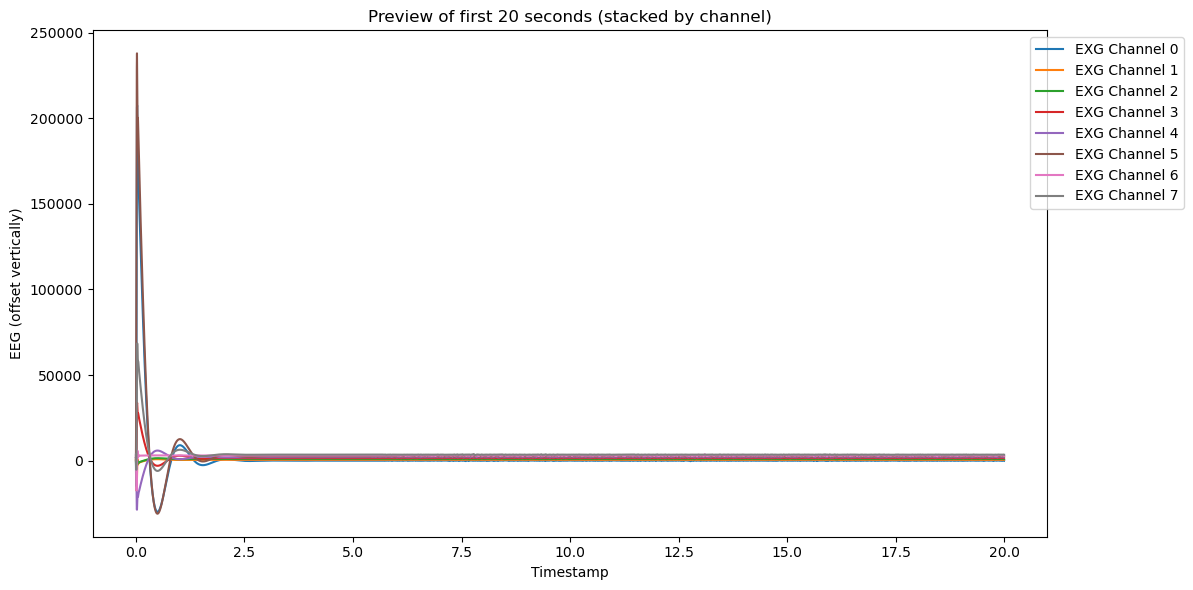

NameError: name 'export_as_brainflow' is not defined

In [12]:
# 1) Find files
file_list = sorted(glob.glob("data/OpenBCI-RAW-*.txt"))
print("Files found:", len(file_list))
for i, fp in enumerate(file_list):
    print(f"  [{i}] {fp}")

# 2) Choose output size
n_channels = int(input("\nEnter number of output channels (8, 12, or 16): "))

# 3) Manual selection with mapping & filtering
dfs, mapping = manual_select_channels_with_mapping(file_list, target_channels=n_channels)

# 4) Merge
final_dataset, mapping_desc = merge_with_mapping(dfs, mapping, max_channels=n_channels, fs=250)

# 5) Optional trim after merge
trim_secs = float(input("Chop off first N seconds after merging (0 = no trim): ") or 0)
final_dataset = chop_after_merge(final_dataset, trim_secs, sample_rate_hz=250)

# 6) Preview plot (first 20 seconds)
duration = 20
n_samples = duration * 250
preview = final_dataset.iloc[:n_samples]

plt.figure(figsize=(12, 6))
for i, col in enumerate([c for c in preview.columns if "EXG" in c]):
    plt.plot(preview["Timestamp"], preview[col] + i*500, label=col)
plt.title("Preview of first 20 seconds (stacked by channel)")
plt.xlabel("Timestamp")
plt.ylabel("EEG (offset vertically)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

# 7) Save CSV + BrainFlow TXT
csv_out = f"Merged_BrainFlow_{n_channels}ch.csv"
txt_out = f"Merged_BrainFlow_{n_channels}ch.txt"

final_dataset.to_csv(csv_out, index=False)
export_as_brainflow(final_dataset, txt_out, sample_rate_hz=250)

print(f"\n✅ Exported: {csv_out} and {txt_out}")
print("\nChannel mapping:")
for m in mapping_desc:
    print("  ", m)


# Input Guideline #
## 8, 0, 1, n, 1, 2, n, 3, 3, n, 1, 4, n, 1, 5, n, 3, 6, n, 3, 7, n, 1, 8, n ##